In [1]:
import gifba
import cobra as cb
import matplotlib.pyplot as plt

In [2]:
# load models and media:
model, media = gifba.utils.load_simple_models("1_1_single")

print("Model type:", type(model)," shape:", len(model))
print("Media:", media)

Set parameter Username


Academic license - for non-commercial use only - expires 2026-12-10
Model type: <class 'list'>  shape: 1
Media: {'EX_A(e)': -10}


In [3]:
# initialize community
community = gifba.gifbaObject(model, 
                              media) # default relative abundance is "equal" or [1/n, ..., 1/n]

# run iterations
media_flux, org_flux = community.run_gifba(iters=5, 
                                           method="pfba", 
                                           v=True)

Read LP format model from file /var/folders/r8/v1wnts2s55n4ch79gpc2shtm0000gn/T/tmpffef2nmh.lp
Reading time = 0.01 seconds
: 4 rows, 10 columns, 16 nonzeros



Iteration: 0

Iteration: 1

Iteration: 2
Converged at iteration 2
Model is periodic and average of the last 1 iterations will be used for flux calculations.


In [4]:
# # run simulation to compare with COBRApy FBA
with model[0] as mdl:
    for ex, flux in media.items():
        mdl.exchanges.get_by_id(ex).lower_bound = flux
    bio1_fba = mdl.optimize().objective_value


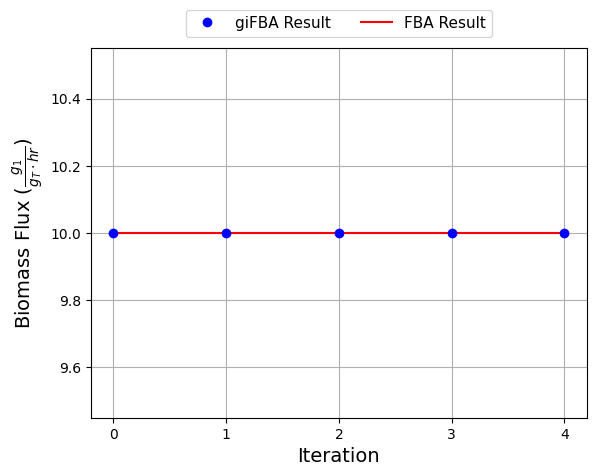

In [5]:
#plot model results
import matplotlib.pyplot as plt
import numpy as np

# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_Bio(e)"]
plt.plot(bio1_gifba, lw=0, marker="o", color="b", label="giFBA Result", zorder=3)

# plot FBA results
plt.plot([bio1_fba]*community.iters, color='r', label='FBA Result', zorder=2)

axis_lab_size = 14
plt.grid()
plt.xlabel("Iteration", fontsize=axis_lab_size)
plt.xticks(np.arange(0, community.iters, 1))
plt.ylabel(r"Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
# plt.ylim(0, 25)
plt.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.125), ncol=2) 

plt.savefig("../../figures/toy_model_figs/paper_figs/1_1_single.svg", bbox_inches='tight')